In [17]:
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 

# needs
# pip install SciencePlots
plt.style.use(['science'])

metrics_dir = "./augmented_datasets_metrics"


In [18]:
headers = ["model", "method", "dataset", "augmentation_rate", "tsed_score"]
all_data = []

for root, _, files in os.walk(metrics_dir):
    if "paraphrase" in root:
        continue

    for file in files:
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(root, file)
        df = pd.read_csv(file_path)

        if df.empty or "augmentation_rate" not in df.columns:
            continue

        df["augmentation_rate"] = df["augmentation_rate"].astype(float)
        # skip all 0.05 steps
        df = df[(df["augmentation_rate"] * 100).astype(int) % 10 == 0]
        df.sort_values("augmentation_rate", inplace=True)

        valid_rates = df["augmentation_rate"].value_counts()
        valid_rates = valid_rates[valid_rates == 5].index
        df = df[df["augmentation_rate"].isin(valid_rates)]
        df = df[df['tsed_score'].notna()]

        if df.empty:
            continue

        for (i, row) in df.iterrows():
            all_data.append([row["model"], row["method"], row["dataset"], row["augmentation_rate"], row["tsed_score"]])

df = pd.DataFrame(all_data, columns=headers)

In [19]:
model_names = {
    "claude": "Claude 3 Haiku",
    "openai": "GPT-4o mini",
    "gemini": "Gemini 2.0 Flash",
    "llama": "Llama 3.3 70B"
}

aug_names = {
    "keyboard": "Keyboard Typos",
    "synonym": "Synonyms",
    "paraphraser": "Paraphrasing"
}

dataset_names = {
    "oldleetcode.json": "LeetCode (Old)",
    "newleetcode.json": "LeetCode (New)",
    "ourdataset.json": "Our Dataset"
}

In [20]:
for model in df["model"].unique().tolist():
    for method in df["method"].unique().tolist():
        mm_df = df[(df["model"] == model) & (df["method"] == method)]
        # print(mm_df.shape)
        stds = mm_df.groupby("augmentation_rate")[["tsed_score"]].std()
        ci = 1.96 * stds["tsed_score"] / len(stds)
        print(f"{model} {method}", (2 * ci).max())


gemini keyboard 0.10420977364258056
gemini synonym 0.09965058009543207
llama keyboard 0.08576295722645176
llama synonym 0.08476240148374732
openai keyboard 0.09272790493744985
openai synonym 0.09310769440561927
claude keyboard 0.08766647436291738
claude synonym 0.08484170961029844


In [21]:
def plot_with_ci(df_to_show, label):
    means = df_to_show.groupby("augmentation_rate")[["tsed_score"]].mean()
    stds = df_to_show.groupby("augmentation_rate")[["tsed_score"]].std()
    ci = 1.96 * stds["tsed_score"] / len(means)

    plt.fill_between(means.index, means["tsed_score"] - ci, means["tsed_score"] + ci, alpha=0.15)
    plt.plot(means.index, means["tsed_score"], label=label)

def setup_figure(title):
    plt.title(title, fontsize=12)
    plt.xlabel("Augmentation rate", fontsize=10)
    plt.ylabel("Code similarity", fontsize=10)
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.grid(True)


def plot_all_models(df, save_label=None):
    for method in df["method"].unique().tolist():
        fig = plt.figure(figsize=(3.54,3.54), dpi=300)

        for model in df["model"].unique().tolist():
            mm_df = df[(df["model"] == model) & (df["method"] == method)]
            plot_with_ci(mm_df, label=model_names[model])

        setup_figure(aug_names[method])
        if save_label is not None:
            save_path = os.path.join("figures", f"{method}_{save_label}.png")
            plt.savefig(save_path, bbox_inches='tight')
        plt.show()

def plot_all_datasets(df, save_label=None):
    for dataset in df["dataset"].unique().tolist():
        fig = plt.figure(figsize=(3.54,3.54), dpi=300)

        for method in df["method"].unique().tolist():
            dm_df = df[(df["dataset"] == dataset) & (df["method"] == method)]
            plot_with_ci(dm_df, label=aug_names[method])

        setup_figure(dataset_names[dataset])
        if save_label is not None:
            save_path = os.path.join("figures", f"{dataset}_{save_label}.png")
            plt.savefig(save_path, bbox_inches='tight')
        plt.show()

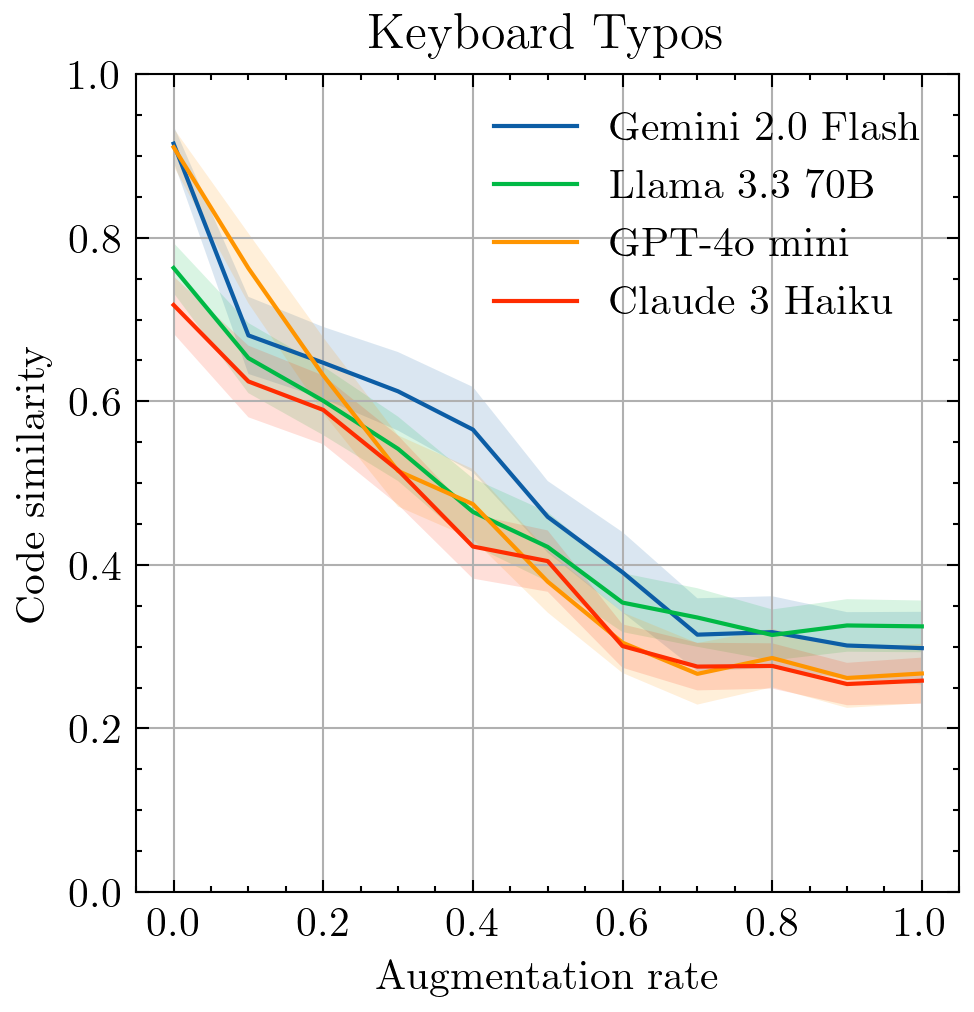

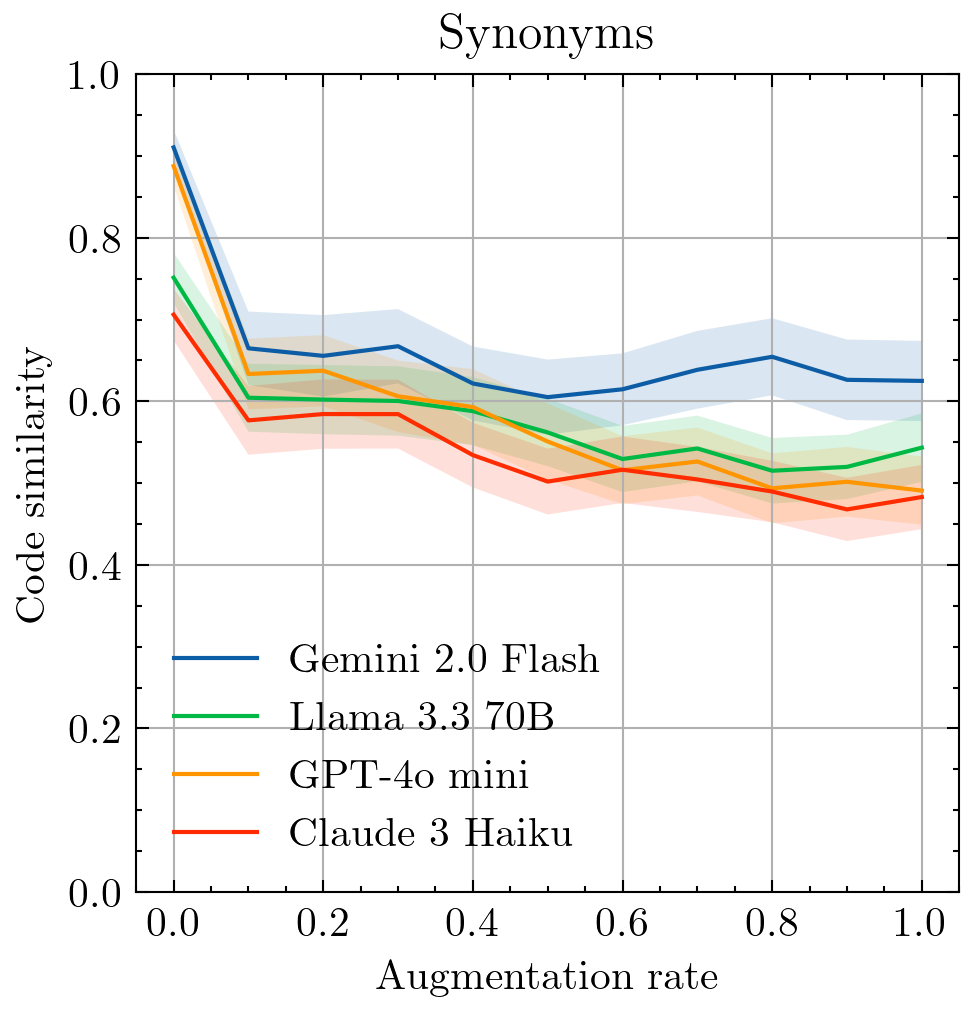

In [22]:
plot_all_models(df, "overall")

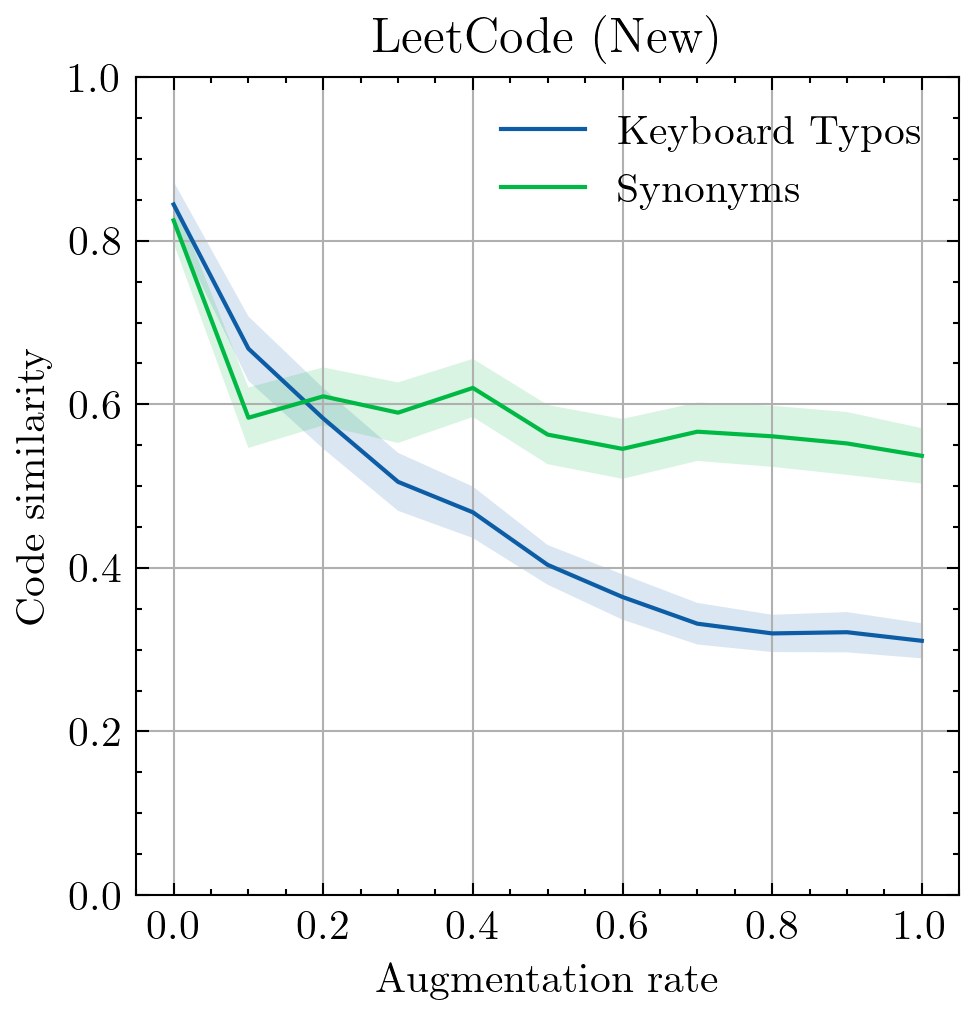

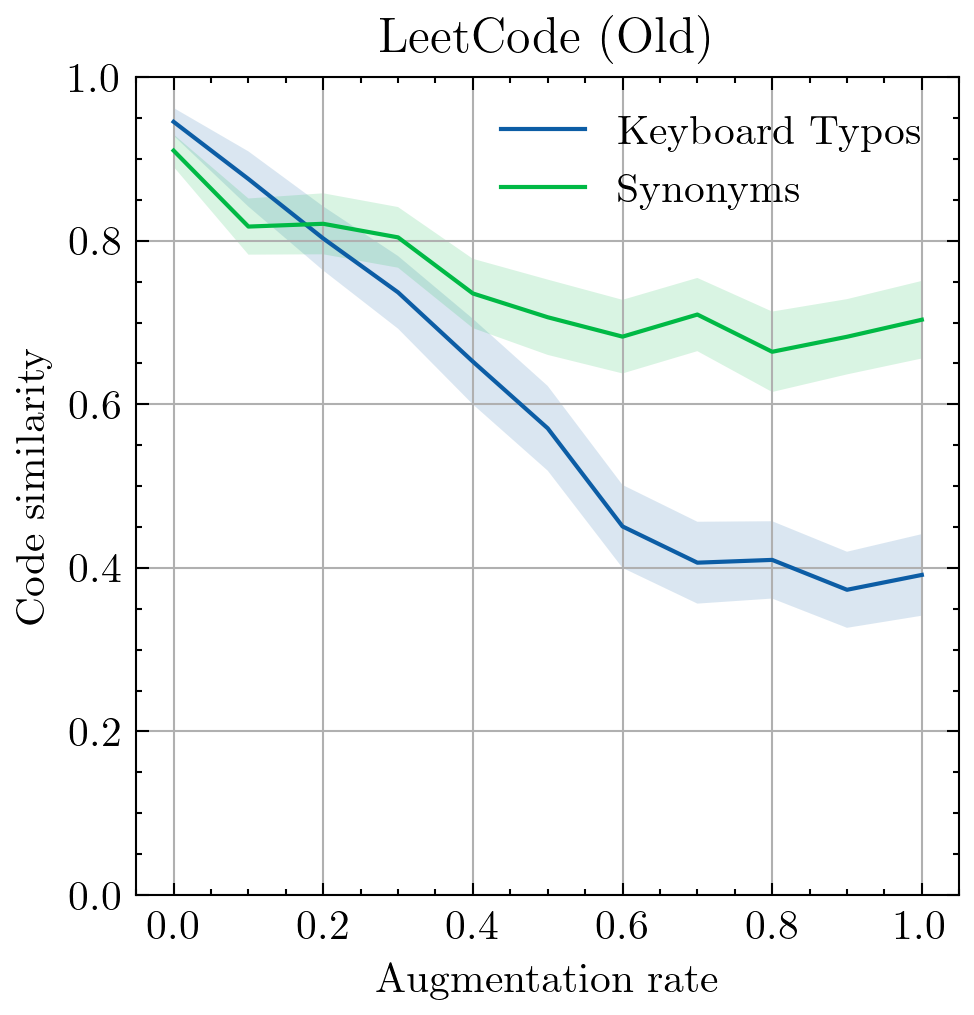

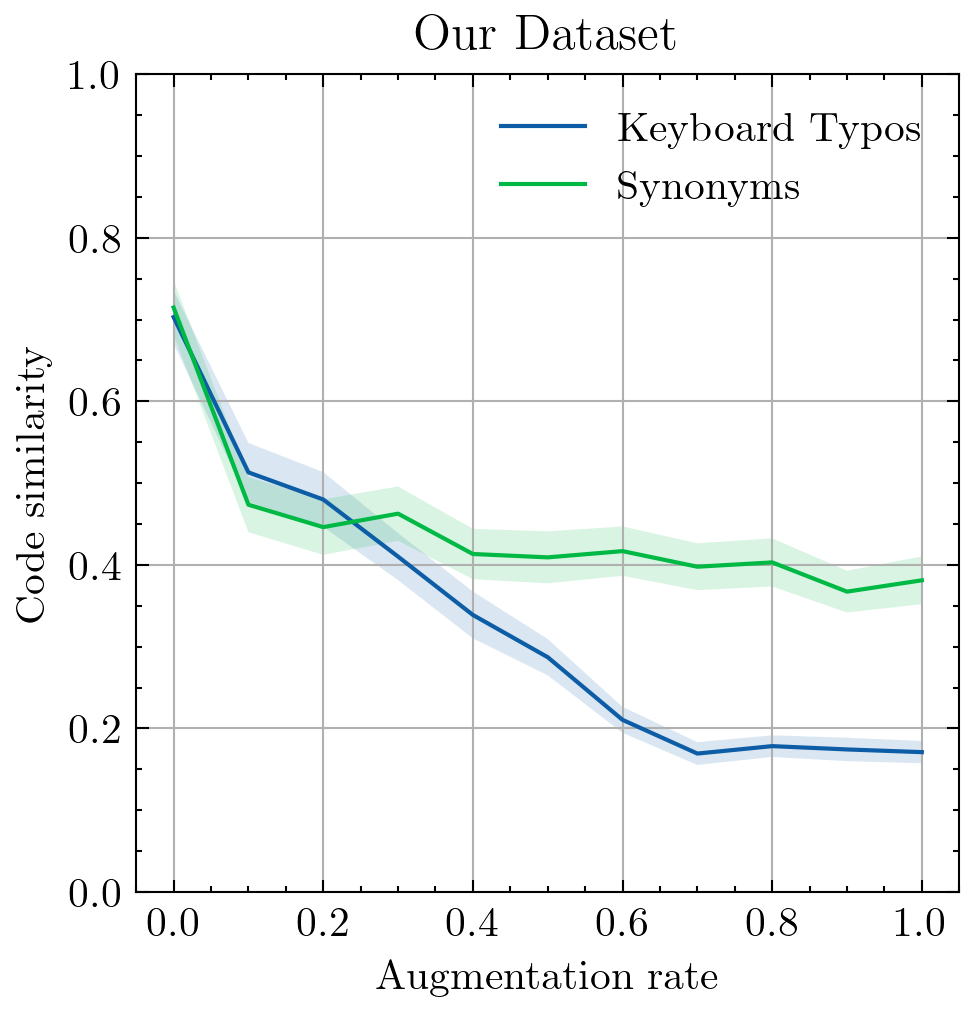

In [23]:
plot_all_datasets(df, "overall")

## Paraphrasing separately

In [27]:
headers = ["model", "dataset", "augmentation_rate", "tsed_score"]
all_data = []

for root, _, files in os.walk(metrics_dir):
    if "paraphrase" not in root:
        continue

    for file in files:
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(root, file)
        df = pd.read_csv(file_path)

        if df.empty or "augmentation_rate" not in df.columns:
            continue

        df["augmentation_rate"] = df["augmentation_rate"].astype(float)
        df.sort_values("augmentation_rate", inplace=True)

        valid_rates = df["augmentation_rate"].value_counts()
        valid_rates = valid_rates[valid_rates == 5].index
        df = df[df["augmentation_rate"].isin(valid_rates)]
        df = df[df['tsed_score'].notna()]

        if df.empty:
            continue

        for (i, row) in df.iterrows():
            all_data.append([row["model"], row["dataset"], row["augmentation_rate"], row["tsed_score"]])

para_df = pd.DataFrame(all_data, columns=headers)

In [28]:
para_df

,model,dataset,augmentation_rate,tsed_score
0,gemini,newleetcode.json,0.0,0.933810
1,gemini,newleetcode.json,0.0,0.933810
2,gemini,newleetcode.json,0.0,0.898571
3,gemini,newleetcode.json,0.0,0.898571
4,gemini,newleetcode.json,0.0,0.933810
...,...,...,...,...
3046,claude,ourdataset.json,0.9,0.205352
3047,claude,ourdataset.json,0.9,0.255086
3048,claude,ourdataset.json,0.9,0.295010
3049,claude,ourdataset.json,0.9,0.207662


In [31]:
para_df["augmentation_rate"].value_counts()

augmentation_rate
0.00    837
0.90    776
0.25    758
0.60    680
Name: count, dtype: int64

/tmp/ipykernel_756/1287912766.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_df = para_df.groupby(['model', 'augmentation_rate']).apply(calculate_stats).reset_index()


Statistics DataFrame:
Unique models: ['claude', 'gemini', 'llama', 'openai']
Unique augmentation rates: [np.float64(0.0), np.float64(0.25), np.float64(0.6), np.float64(0.9)]

Processing model: claude
  Original: mean=0.629, ci=0.022
  Low: mean=0.508, ci=0.027
  Medium: mean=0.467, ci=0.027
  High: mean=0.461, ci=0.027
  Plotted bars at positions: [-0.27  0.73  1.73  2.73]

Processing model: gemini
  Original: mean=0.897, ci=0.016
  Low: mean=0.627, ci=0.031
  Medium: mean=0.485, ci=0.032
  High: mean=0.490, ci=0.030
  Plotted bars at positions: [-0.09  0.91  1.91  2.91]

Processing model: llama
  Original: mean=0.738, ci=0.022
  Low: mean=0.576, ci=0.031
  Medium: mean=0.508, ci=0.030
  High: mean=0.465, ci=0.023
  Plotted bars at positions: [0.09 1.09 2.09 3.09]

Processing model: openai
  Original: mean=0.879, ci=0.018
  Low: mean=0.660, ci=0.034
  Medium: mean=0.603, ci=0.040
  High: mean=0.507, ci=0.035
  Plotted bars at positions: [0.27 1.27 2.27 3.27]


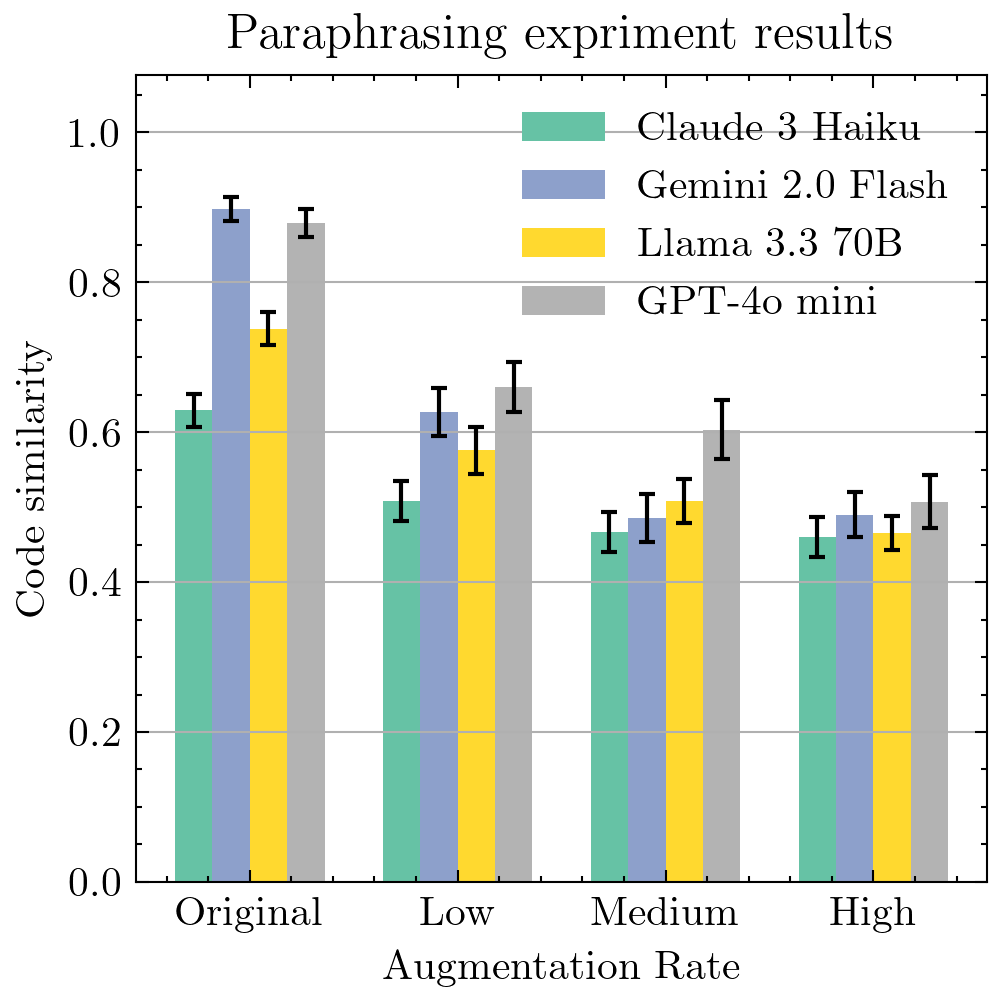

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Create a mapping for augmentation rates to labels
aug_rate_mapping = {0.0: 'Original', 0.25: 'Low', 0.6: 'Medium', 0.9: 'High'}

# Calculate mean and 95% confidence intervals for each model and augmentation rate
def calculate_stats(group):
    if len(group) == 0:
        return pd.Series({'mean': 0, 'ci': 0, 'count': 0})
    
    mean = group['tsed_score'].mean()
    n = len(group)
    
    if n > 1:
        sem = stats.sem(group['tsed_score'])  # Standard error of the mean
        ci = sem * stats.t.ppf((1 + 0.95) / 2., n - 1)  # 95% CI
    else:
        ci = 0
    
    return pd.Series({'mean': mean, 'ci': ci, 'count': n})

# Group by model and augmentation_rate, then calculate stats
stats_df = para_df.groupby(['model', 'augmentation_rate']).apply(calculate_stats).reset_index()

# Debug: Print the stats dataframe to see what we have
print("Statistics DataFrame:")
print(f"Unique models: {sorted(stats_df['model'].unique())}")
print(f"Unique augmentation rates: {sorted(stats_df['augmentation_rate'].unique())}")

# Create the plot
# fig, ax = plt.subplots(figsize=(14, 8))
fig = plt.figure(figsize=(3.54,3.54), dpi=300)

# Get unique models and augmentation rates
models = sorted(para_df['model'].unique())
aug_rates = [0.0, 0.25, 0.6, 0.9]
aug_labels = [aug_rate_mapping[rate] for rate in aug_rates]

# Set up the bar positions
n_models = len(models)
n_aug_rates = len(aug_rates)
bar_width = 0.18
x = np.arange(n_aug_rates)

# Colors for each model
colors = plt.cm.Set2(np.linspace(0, 1, n_models))

# Create bars for each model
for i, model in enumerate(models):
    means = []
    cis = []
    
    print(f"\nProcessing model: {model}")
    
    for aug_rate in aug_rates:
        # Filter data for this specific model and augmentation rate
        model_data = stats_df[(stats_df['model'] == model) & 
                             (stats_df['augmentation_rate'] == aug_rate)]
        
        if not model_data.empty:
            mean_val = model_data['mean'].iloc[0]
            ci_val = model_data['ci'].iloc[0]
            means.append(mean_val)
            cis.append(ci_val)
            print(f"  {aug_rate_mapping[aug_rate]}: mean={mean_val:.3f}, ci={ci_val:.3f}")
        else:
            means.append(0)
            cis.append(0)
            print(f"  {aug_rate_mapping[aug_rate]}: No data found")
    
    # Calculate x positions for this model's bars
    x_pos = x + (i - (n_models-1)/2) * bar_width
    
    # Create bars with error bars
    bars = plt.bar(x_pos, means, bar_width, 
                  label=model_names[model], color=colors[i], #alpha=0.8,
                  yerr=cis, capsize=2, linewidth=1.5)
    
    print(f"  Plotted bars at positions: {x_pos}")

# Customize the plot
plt.xlabel('Augmentation Rate', fontsize=10)
plt.ylabel('Code similarity', fontsize=10)
plt.title('Paraphrasing expriment results', fontsize=12)
plt.xticks(x, aug_labels)
plt.legend(loc='best')
plt.grid(True, axis='y')
plt.ylim(0, min(1.1, max(stats_df['mean']) * 1.2))  # Adjust based on data

# Add some styling
plt.tight_layout()

save_path = os.path.join("figures", "paraphrasing_results.png")
plt.savefig(save_path, bbox_inches='tight')
plt.show()